# Assignment: Exploratory Data Analysis


**Q1.** To compute the sample mean of a variable $X$:
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Instead of the mean, consider the median. Consider transformations that are non-decreasing (if $x\ge x'$, then $g(x)\ge g(x')$), like $2+5 \times X$ or $\text{arcsinh}(X)$. Is a non-decreasing transformation of the median the median of the transformed variable? Explain. Does your answer apply to any quantile? The IQR? The range?
5. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

Answers attached as separate file in assignment folder

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions.
7. Which giftors provide the most money, in total?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# 1

gift_data = pd.read_csv("ForeignGifts_edu.csv")

gift_data.head(10)

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
5,6,105100,University of Alabama,Tuscaloosa,AL,43501,30231,Contract,KUWAIT,Kuwait-Embassy of the State
6,7,105100,University of Alabama,Tuscaloosa,AL,43507,30162,Contract,KUWAIT,Kuwait-Embassy of the State
7,8,105100,University of Alabama,Tuscaloosa,AL,43517,200,Monetary Gift,GERMANY,"Mercedes-Benz U.S. International, I"
8,9,105100,University of Alabama,Tuscaloosa,AL,43529,5136,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
9,10,105100,University of Alabama,Tuscaloosa,AL,43531,57049,Contract,JAPAN,Kansai Gaidai University (KGU)


,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


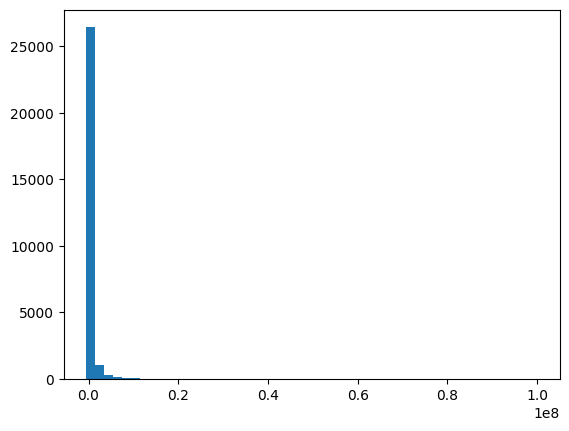

In [3]:
# 2

plt.hist(gift_data["Foreign Gift Amount"], bins = 50)

gift_data["Foreign Gift Amount"].describe()

# Examining the variable and the histogram shows a heavy right skew, with some very large donations increasing the average.
# There are some outliers, which are the extremely large gifts.
# Additionally, the minimum gift amount is a negative number, which may be a mistake in the data or a refund of a gift.

(array([1.0936e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.7274e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.1000e+01]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

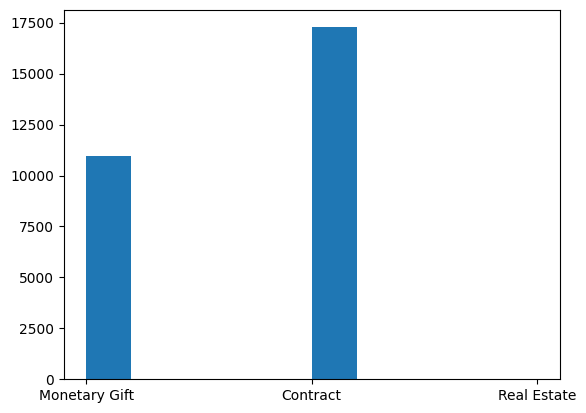

In [4]:
# 3

plt.hist(gift_data["Gift Type"])

In [5]:
gift_counts = gift_data["Gift Type"].value_counts()

gift_props = gift_counts / gift_counts.sum()

print(gift_props)

# 61.2 percent of gifts are contracts, 38.7% are Monetary Gifts, and Real Estate Gifts make up .04%

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: count, dtype: float64


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='log', ylabel='Density'>

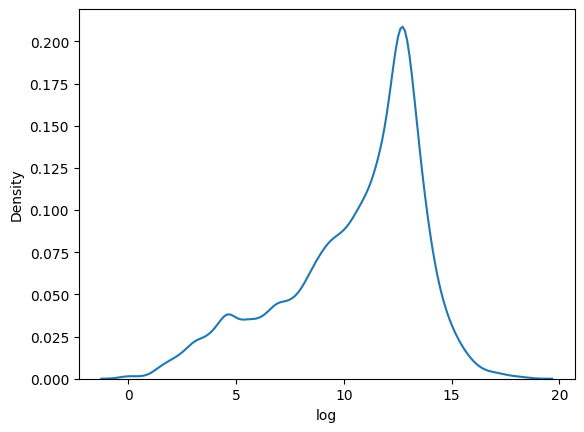

In [6]:
# 4

gift_data["log"] = np.log(gift_data["Foreign Gift Amount"])

sns.kdeplot(gift_data["log"])

<Axes: xlabel='log', ylabel='Density'>

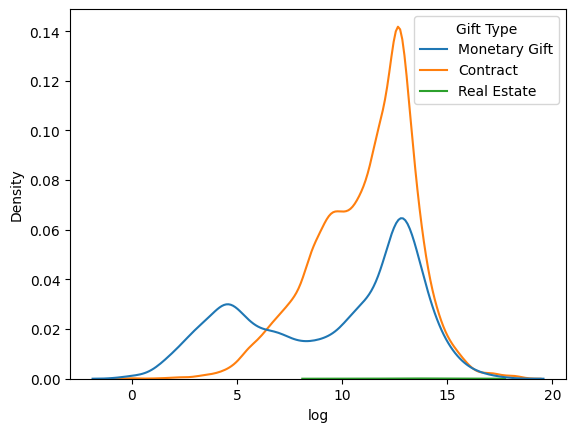

In [7]:
# Conditional on gift type

sns.kdeplot(gift_data, x = "log", hue = "Gift Type")

# Doing a log transformation makes the gift sizes appear more normal and there is less skewness.
# The kernal density plot conditional on gift type reveals that contracts peak at the highest log values.

In [8]:
# 5

top_15 = gift_data.groupby("Country of Giftor").count()["Foreign Gift Amount"].sort_values(ascending = False).head(15)

print(top_15)

top_15_amount_given = gift_data.groupby("Country of Giftor").sum(numeric_only=True)["Foreign Gift Amount"].sort_values(ascending = False).head(15)

print(top_15_amount_given)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

In [9]:
# 6

top_15_inst = gift_data.groupby("Institution Name").sum(numeric_only = True)["Foreign Gift Amount"].sort_values(ascending = False).head(15)

print(top_15_inst)

Institution Name
Carnegie Mellon University                       1477922504
Cornell University                               1289937761
Harvard University                                954803610
Massachusetts Institute of Technology             859071692
Yale University                                   613441311
Texas A&M University                              521455050
Johns Hopkins University                          502409595
Northwestern University                           402316221
Georgetown University                             379950511
University of Chicago (The)                       364544338
University of Colorado Boulder                    360173159
Duke University                                   343699498
Brigham Young University                          323509863
Stanford University                               319561362
University of Texas MD Anderson Cancer Center     301527419
Name: Foreign Gift Amount, dtype: int64


(array([279.,  12.,   5.,   6.,   7.,   2.,   1.,   1.,   1.,   0.,   0.,
          1.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,   1.]),
 array([5.00000000e+02, 7.38966002e+07, 1.47792700e+08, 2.21688801e+08,
        2.95584901e+08, 3.69481001e+08, 4.43377101e+08, 5.17273201e+08,
        5.91169302e+08, 6.65065402e+08, 7.38961502e+08, 8.12857602e+08,
        8.86753702e+08, 9.60649803e+08, 1.03454590e+09, 1.10844200e+09,
        1.18233810e+09, 1.25623420e+09, 1.33013030e+09, 1.40402640e+09,
        1.47792250e+09]),
 <BarContainer object of 20 artists>)

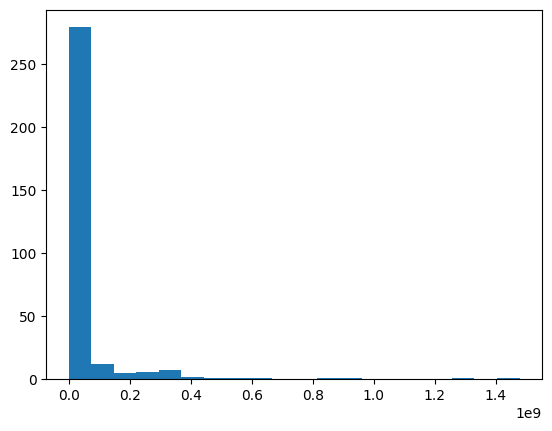

In [10]:
inst_totals = gift_data.groupby("Institution Name").sum(numeric_only = True)["Foreign Gift Amount"]

plt.hist(inst_totals, bins = 20)

In [11]:
# 7

top_giftors = gift_data.groupby("Giftor Name").sum(numeric_only = True)["Foreign Gift Amount"].sort_values(ascending = False).head(15)

print(top_giftors)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


**Q3.** This question uses the Airbnb data to practice making visualizations.

  1. Load the `./data/airbnb_hw.csv` data with Pandas. This provides a dataset of AirBnB rental properties for New York City.  
  2. What are are the dimensions of the data? How many observations are there? What are the variables included? Use `.head()` to examine the first few rows of data.
  3. Cross tabulate `Room Type` and `Property Type`. What patterns do you see in what kinds of rentals are available? For which kinds of properties are private rooms more common than renting the entire property?
  4. For `Price`, make a histogram, kernel density, box plot, and a statistical description of the variable. Are the data badly scaled? Are there many outliers? Use `log` to transform price into a new variable, `price_log`, and take these steps again.
  5. Make a scatterplot of `price_log` and `Beds`. Describe what you see. Use `.groupby()` to compute a desciption of `Price` conditional on/grouped by the number of beds. Describe any patterns you see in the average price and standard deviation in prices.
  6. Make a scatterplot of `price_log` and `Beds`, but color the graph by `Room Type` and `Property Type`. What patterns do you see? Compute a description of `Price` conditional on `Room Type` and `Property Type`. Which Room Type and Property Type have the highest prices on average? Which have the highest standard deviation? Does the mean or median appear to be a more reliable estimate of central tendency, and explain why?
  7. We've looked a bit at this `price_log` and `Beds` scatterplot. Use seaborn to make a `jointplot` with `kind=hex`. Where are the data actually distributed? How does it affect the way you think about the plots in 5 and 6?

In [12]:
#1

airbnb_data = pd.read_csv("airbnb_hw.csv")

#2

airbnb_data.shape # The shape is (30478, 13). There are 30478 observations and 13 variables. Some variables included are Name, Neighborhood, Property Type, Room Type, Zipcode.

airbnb_data.head(5)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [13]:
# 3

pd.crosstab(airbnb_data['Room Type'], airbnb_data['Property Type'])

# Apartments are the most available types of rentals. For private room rentals, bed and breakfasts have more options.

Property Type,Apartment,Bed & Breakfast,Boat,Bungalow,Cabin,Camper/RV,Castle,Chalet,Condominium,Dorm,House,Hut,Lighthouse,Loft,Other,Tent,Townhouse,Treehouse,Villa
Room Type,,,,,,,,,,,,,,,,,,,
Entire home/apt,15669,13,7,4,1,6,0,0,72,4,752,0,1,392,14,0,83,0,4
Private room,10748,155,1,0,1,1,1,1,22,16,1258,2,0,312,29,4,52,1,4
Shared room,685,12,0,0,0,0,0,0,0,11,80,0,0,49,4,0,1,3,0


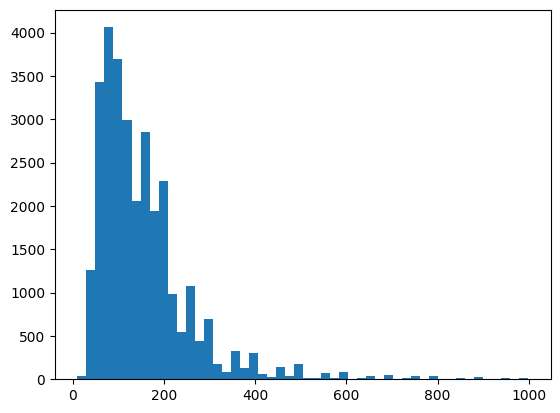

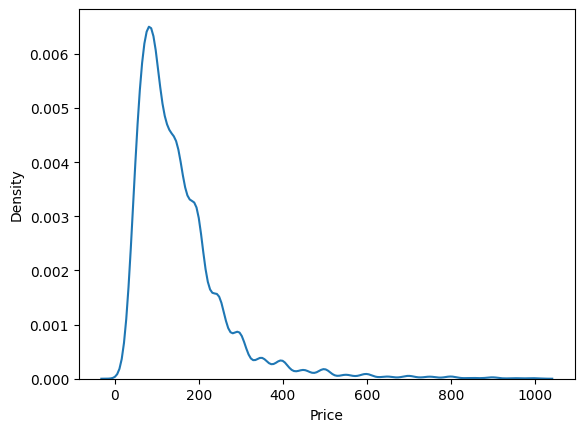

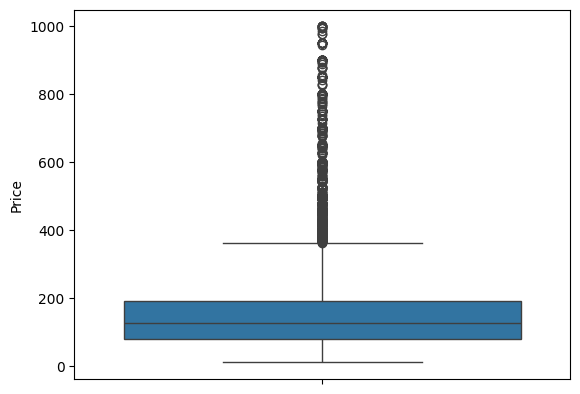

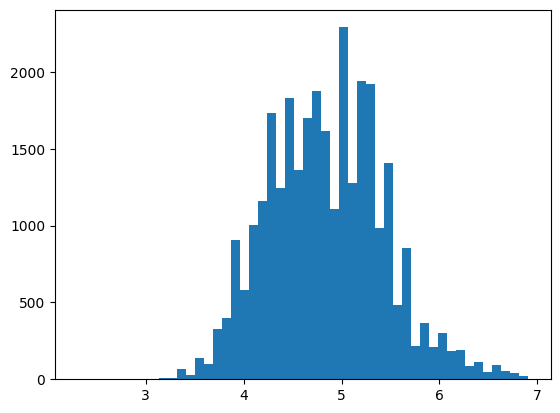

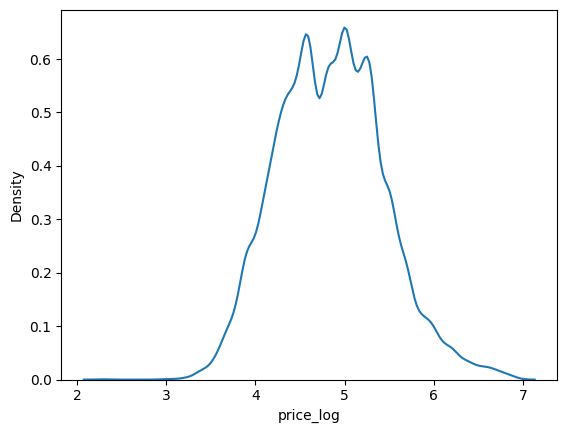

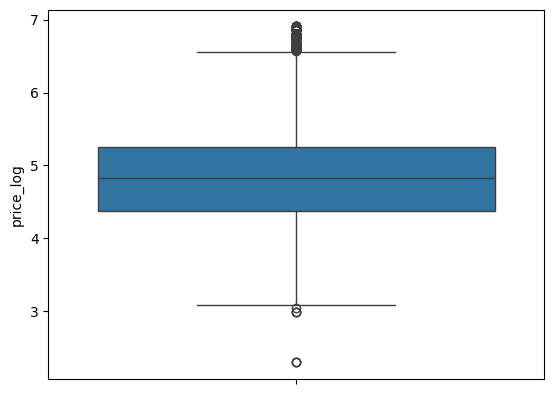

,price_log
count,30297.000000
mean,4.845370
std,0.596999
min,2.302585
25%,4.382027
50%,4.828314
75%,5.257495
max,6.906755


In [14]:
# 4

airbnb_data['Price'] = pd.to_numeric(airbnb_data['Price'], errors='coerce')

# Histogram
plt.hist(airbnb_data["Price"], bins = 50)
plt.show()

# Kernal density plot
sns.kdeplot(airbnb_data, x = "Price")
plt.show()

# Boxplot

sns.boxplot(y = airbnb_data["Price"])
plt.show()

# Describing the variable
airbnb_data["Price"].describe()

# There is a right skew to the price variable. Examining the boxplot, it is clear that there are numerous outliers.

# Repeating with log transformation

airbnb_data["price_log"] = np.log(airbnb_data["Price"])

# Histogram
plt.hist(airbnb_data["price_log"], bins = 50)
plt.show()

# Kernal density plot
sns.kdeplot(airbnb_data, x = "price_log")
plt.show()

# Boxplot

sns.boxplot(y = airbnb_data["price_log"])
plt.show()

# Describing the variable
airbnb_data["price_log"].describe()

# After the log transformation, the distribution looks more normal.


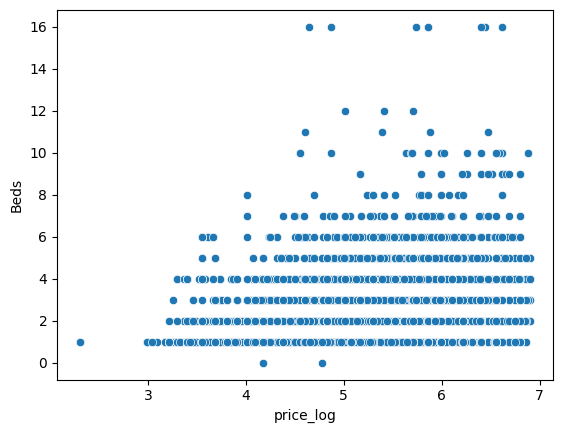

,count,mean,std,min,25%,50%,75%,max
Beds,,,,,,,,
0.0,2.0,92.000000,38.183766,65.0,78.50,92.0,105.50,119.0
1.0,20307.0,124.757670,75.685752,10.0,75.00,100.0,155.00,950.0
2.0,6561.0,186.702332,115.044205,25.0,115.00,160.0,225.00,999.0
3.0,2029.0,234.928043,142.288189,26.0,140.00,200.0,299.00,999.0
4.0,766.0,280.554830,175.512312,27.0,150.00,240.0,363.75,999.0
5.0,274.0,322.000000,190.319415,35.0,186.00,285.0,425.00,995.0
6.0,166.0,316.313253,201.157585,35.0,183.75,271.0,399.00,900.0
7.0,45.0,341.377778,220.116631,55.0,177.00,300.0,445.00,900.0
8.0,20.0,331.850000,155.652202,55.0,218.75,339.5,408.75,750.0


In [15]:
# 5

sns.scatterplot(data = airbnb_data, x = "price_log", y = "Beds")
plt.show()

# As the number of beds increases, price increases. This makes sense, because if you're willing to spend more money,
# you will have more options for how many beds.

airbnb_data.groupby("Beds")["Price"].describe()

# Generally speaking, the mean and standard deviation of the price variable increase as beds increase. However, there are
# a few points where this is not true.

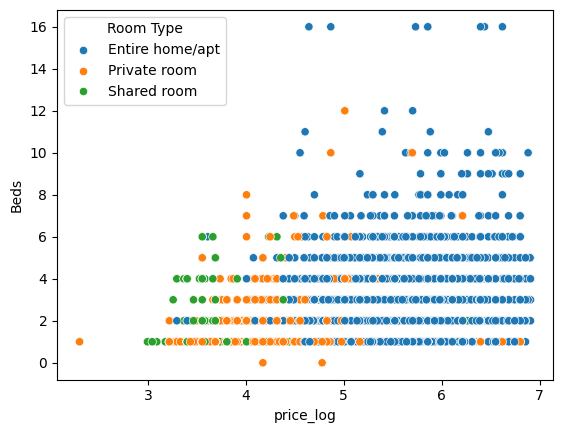

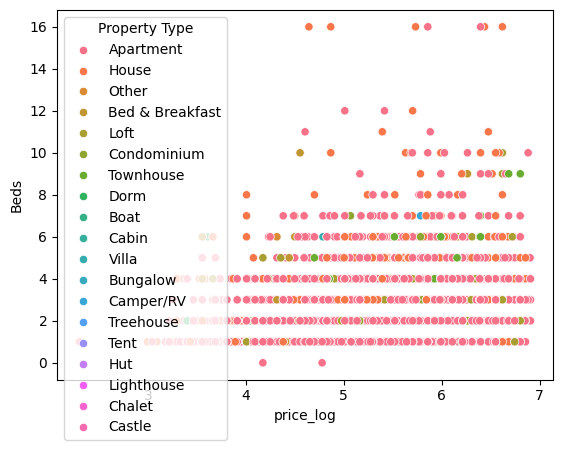

,count,mean,std,min,25%,50%,75%,max
Room Type,,,,,,,,
Entire home/apt,16855.0,204.061525,116.531136,10.0,135.0,175.0,239.0,999.0
Private room,12599.0,90.663227,47.914195,10.0,65.0,80.0,100.0,999.0
Shared room,843.0,76.553974,65.756210,10.0,45.0,60.0,85.0,950.0


In [16]:
# 6

sns.scatterplot(data = airbnb_data, x = "price_log", y = "Beds", hue = "Room Type")
plt.show()

# Coloring by room type shows that the higher price points consist mostly of entire homes and apartments.
# The lower price points have more private and shared rooms.

sns.scatterplot(data = airbnb_data, x = "price_log", y = "Beds", hue = "Property Type")
plt.show()

# Coloring by property type reveals that apartments make up a large portion of the data.


airbnb_data.groupby("Room Type")["Price"].describe()
#airbnb_data.groupby("Property Type")["Price"].describe()
# The room type with the highest prices on average are the entire home/apartment type.
# The room type with the highest standard deviation is also the entire home/apartment type.

# The property type with the highest price on average is the Condominium.
# The highest standard deviation is the "Other" type.

# I think the median is more reliable, due to the outliers that would skew the mean.




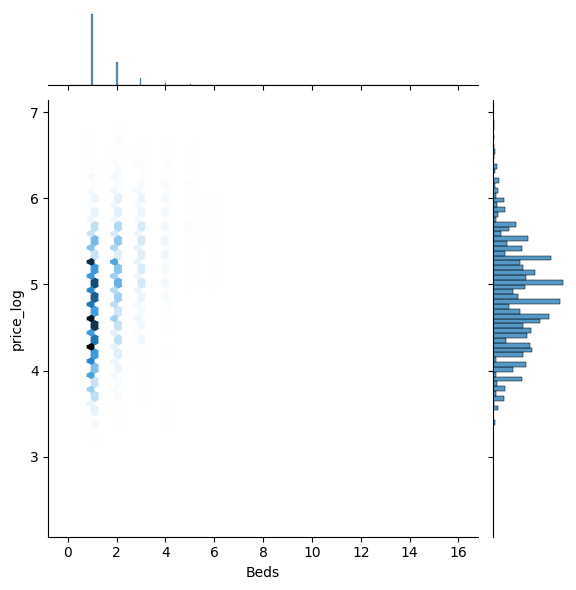

In [17]:
# 7

sns.jointplot(data = airbnb_data, x = "Beds", y = "price_log", kind = "hex")

# Most of the data in the airbnb dataset is for rentals with a low number of beds.
# This affects the way I look at the plots made in part 5 and 6 because it shows that there are lots of more data points for rentals with low beds.

**Q4.** This question looks at a time series of the number of active oil drilling rigs in the United States over time. The data comes from the Energy Information Agency.

1. Load `./data/drilling_rigs.csv` and examine the data. How many observations? How many variables? Are numeric variables correctly read in by Pandas, or will some variables have to be typecast/coerced? Explain clearly how these data need to be cleaned.
2. To convert the `Month` variable to an ordered datetime variable, use `df['time'] = pd.to_datetime(df['Month'], format='mixed')`.
3. Let's look at `Active Well Service Rig Count (Number of Rigs)`, which is the total number of rigs over time. Make a line plot of this time series. Describe what you see.
4. Instead of levels, we want to look at change over time. Compute the first difference of  `Active Well Service Rig Count (Number of Rigs)` and plot it over time. Describe what you see.
5. The first two columns are the number of onshore and offshore rigs, respectively. Melt these columns and plot the resulting series.

In [18]:
# 1

df = pd.read_csv("drilling_rigs.csv")

df.shape[0] # 623 observations

df.shape[1] # 10 variables
df.head(10)

df.info()

# Some variables are not properly read in as integers. These variables will need to be changed to integers, and errors will need to be coerced.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 10 columns):
 #   Column                                                                                       Non-Null Count  Dtype 
---  ------                                                                                       --------------  ----- 
 0   Month                                                                                        623 non-null    object
 1   Crude Oil and Natural Gas Rotary Rigs in Operation, Onshore (Number of Rigs)                 623 non-null    int64 
 2   Crude Oil and Natural Gas Rotary Rigs in Operation, Offshore (Number of Rigs)                623 non-null    int64 
 3   Crude Oil Rotary Rigs in Operation, Total (Number of Rigs)                                   623 non-null    object
 4   Natural Gas Rotary Rigs in Operation, Total (Number of Rigs)                                 623 non-null    object
 5   Crude Oil and Natural Gas Rotary Rigs in Op

In [19]:
# 2

df["time"] = pd.to_datetime(df["Month"], format = 'mixed')

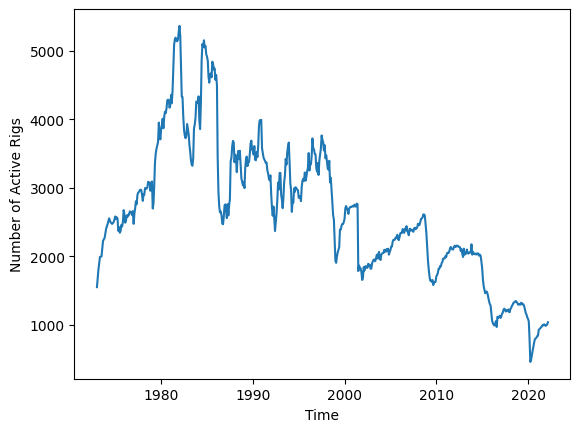

In [20]:
# 3

df["Active Well Service Rig Count (Number of Rigs)"] = pd.to_numeric(df["Active Well Service Rig Count (Number of Rigs)"], errors="coerce")

plt.plot(df["time"], df["Active Well Service Rig Count (Number of Rigs)"])
plt.xlabel("Time")
plt.ylabel("Number of Active Rigs")
plt.show()

# Number of rigs fluctuates. It peaked between 1980 and 1990, and has been decreasing since.

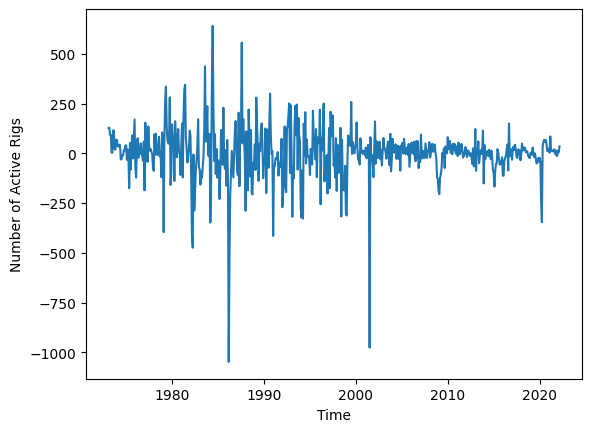

In [21]:
# 4

df["rig_first_diff"] = df["Active Well Service Rig Count (Number of Rigs)"].diff()

plt.plot(df["time"], df["rig_first_diff"])
plt.xlabel("Time")
plt.ylabel("Number of Active Rigs")
plt.show()

# There are fluctuations around 0. Noticeable spikes around 1985, 2000, and 2020.

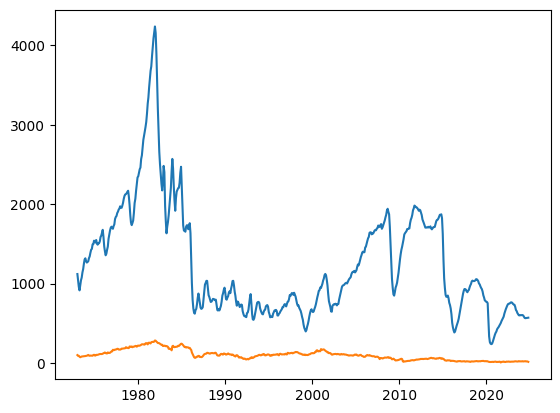

In [22]:
# 5


rigs = df.melt(id_vars = "time", value_vars = ["Crude Oil and Natural Gas Rotary Rigs in Operation, Onshore (Number of Rigs)", "Crude Oil and Natural Gas Rotary Rigs in Operation, Offshore (Number of Rigs)"], var_name = "Rig Type", value_name = "Number of Rigs")

for x in rigs["Rig Type"].unique():
  subset = rigs[rigs["Rig Type"] == x]
  plt.plot(subset["time"], subset["Number of Rigs"], label = x)